# Multivariate Statistical Process Control
## The Multivariate EWMA (MEWMA) Control Chart
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Recap: The Limits of Hotelling's $T^2$](#recap-the-limits-of-hotellings-t2)
2. [The Multivariate EWMA Chart](#the-multivariate-ewma-chart)
3. [The MEWMA Plotting Statistic](#the-mewma-plotting-statistic)
4. [Choosing $H$](#choosing-h)
5. [Worked Example: Soda Can Filling Lines](#worked-example-soda-can-filling-lines)
6. [Post-Hoc Analysis: Which Line Went OOC?](#post-hoc-analysis-which-line-went-ooc)
7. [Final Thoughts on Multivariate SPC](#final-thoughts-on-multivariate-spc)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

#setwd("Slides//Week-9-MEWMA-Chart")

## Recap: The Limits of Hotelling's $T^2$

Last time, we saw why monitoring related quality characteristics separately is a bad idea: it inflates the true false alarm rate and can miss joint patterns that no single chart would ever catch. Hotelling's $T^2$ chart solved that by generalizing the Shewhart $\bar{X}$ chart into multiple dimensions at once.

But that word — *Shewhart* — is a clue to its remaining weakness. Just like the univariate $\bar{X}$ chart, $T^2$ only uses information from the **most recent sample** in its plotting statistic. It's efficient at catching large, sudden shifts, but (exactly as with the univariate case) it's not great at catching small, sustained drifts.

We already solved this problem once, in the univariate world, with the EWMA chart. So the natural move here is the same one: extend EWMA into multiple dimensions. That gives us the **Multivariate EWMA (MEWMA)** chart.

## The Multivariate EWMA Chart

The MEWMA is a direct, logical extension of the univariate EWMA chart. The vector $\mathbf{Z_i}$ is defined as:

$$ \mathbf{Z_i} = \lambda\left(\mathbf{x_i} - \bar{\bar{\mathbf{x}}}\right) + (1-\lambda)\mathbf{Z_{i-1}} $$

where $0\leq\lambda\leq 1$ is the same smoothing constant we used in the univariate EWMA chart, and $\mathbf{Z_0 = 0}$. Just like before, smaller $\lambda$ means more weight on history (more sensitive to small, sustained shifts); larger $\lambda$ means more weight on the newest observation.

## The MEWMA Plotting Statistic

The actual quantity plotted is:

$$ \mathbf{T_i^2 = Z^T_i\Sigma^{-1}_{Z_i}Z_i} $$

where $\Sigma_{Z_i}$ is the variance-covariance matrix of $\mathbf{Z_i}$:

$$ \frac{\lambda}{2-\lambda}\bigg[1-(1-\lambda)^{2i}\bigg]\mathbf{\Sigma} $$

If you squint, this is exactly the same shape as the univariate EWMA variance formula from a couple weeks ago — $\frac{\lambda}{2-\lambda}(1-(1-\lambda)^{2i})$ — just now scaling the full covariance matrix $\mathbf{\Sigma}$ instead of a scalar $\sigma^2$, and folded into a quadratic form the same way $T^2$ was.

## Choosing $H$

If $\mathbf{T^2_i} > H$, we declare the process out of control. Choosing $H$ works differently than choosing a $3\sigma$-style limit. It depends on both the number of variables (streams) being monitored and the size of shift you want to reliably detect. Reference tables (widely published, and included with this week's lecture materials) let you look up an appropriate $H$ to hit a target $ARL_0$ for a given number of streams and shift size. This is conceptually the same design exercise as picking $L$ and $\lambda$ for a univariate EWMA chart, just extended to account for dimensionality.

## Worked Example: Soda Can Filling Lines

Let's revisit the soda can filling line example from the $T^2$ chart notebook, this time building an MEWMA chart instead. As before, we're monitoring **three** filling lines simultaneously, with $m=25$ Phase I samples of size $n=10$ per line.

In [2]:
## Load the Libraries ##

library(tidyverse)
library(readxl)
library(qcc)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Reload the data and Phase I estimates

We'll re-read the same canning data and re-run `mqcc` to recover the Phase I mean vector and covariance matrix — the same estimates the $T^2$ chart used — since those are exactly what the MEWMA calculation needs as its center and scale.

In [5]:
## Read in Phase I Canning Data as List ##

sn <- excel_sheets("Can Volume Data.xlsx")

cans <- lapply(sn,FUN=function(x){
  
  d <- read_xlsx("Can Volume Data.xlsx",sheet=x) %>%
    dplyr::select(-`Sample Number`,-`Line Number`)
  
  return(d)
  
})

names(cans) <- paste("Line",1:3,sep="")

## Recover Phase I mean vector and covariance matrix (as computed for the T2 chart) ##

t2 <- mqcc(cans,type='T2',plot=F)

In [6]:
## Read in Phase II Can Volume Data ##

sn2 <- excel_sheets("Can Volume Phase II Data.xlsx")

cans2 <- lapply(sn2,FUN=function(x){
  
  d <- read_xlsx("Can Volume Phase II Data.xlsx",sheet=x) %>%
    dplyr::select(-`Sample`,-`Line Number`)
  
  return(d)
  
})

names(cans2) <- paste("Line",1:3,sep="")

### Setting up the mean vector and covariance matrix

In [7]:
## Use Phase I estimates of mean and v-c matrix
## from Hotelling's T2 ##

mean_vec <- t2$center
cov_mat <- t2$cov

### Arranging the data and centering it

We need each sample's row-wise mean across the three lines, then center those means around the Phase I mean vector — exactly analogous to the $\bar{x}_i - \mu_0$ step in the univariate EWMA calculation, just done for a vector instead of a scalar.

In [13]:
## Must arrange data in the right format and center ##

p1_means <- as.matrix(
  
  sapply(cans,FUN=function(x){
    
    return(rowMeans(x))
  
  })

)

p1_means_centered <- t(
  
  apply(p1_means,1,FUN=function(x){
  
  return(x - mean_vec)
  
  })
  
)

p2_means <- as.matrix(
  
  sapply(cans2,FUN=function(x){
    
    return(rowMeans(x))
  
  })

)

p2_means_centered <- t(
  
  apply(p2_means,1,FUN=function(x){
  
  return(x - mean_vec)
  
  })
  
)

### Choosing $\lambda$ and building the $\Sigma_Z$ helper function

We'll use $\lambda = 0.10$, consistent with a fairly sensitive chart designed to catch small, sustained shifts. First, a small helper function to compute $\Sigma_{Z_i}$ at each time step $i$.

In [ ]:
## Let's set lambda to 0.1 ##

lambda <- 0.10

## Write Function to Calculate Sigma_Z ##

sigma_z <- function(lambda,vc_matrix,t){
  
  c <- (lambda/(2-lambda))*(1-(1-lambda)^(2*t))
  
  return(c*vc_matrix)
  
}

### Calculating $\mathbf{Z_i}$ for Phase I and Phase II

Same recursive structure as the univariate EWMA loop from a couple weeks ago, just operating on row vectors instead of scalars.

In [ ]:
## Write Function to Calculate Z Statistic ##

Z1 <- matrix(0,nrow=nrow(p1_means),ncol=3)

for(i in 1:nrow(p1_means)){
  
  if(i == 1){
    
    Z1[i,] <- lambda*t(p1_means_centered[i,])
    
  } else {
    
    Z1[i,] <- lambda*t(p1_means_centered[i,]) + (1-lambda)*Z1[i-1]
    
  }
  
}

In [14]:
Z2 <- matrix(0,nrow=nrow(p2_means),ncol=3)

for(i in 1:nrow(p2_means)){
  
  if(i == 1){
    
    Z2[i,] <- lambda*t(p2_means_centered[i,])
    
  } else {
    
    Z2[i,] <- lambda*t(p2_means_centered[i,]) + (1-lambda)*Z2[i-1]
    
  }
  
}

### Calculating the MEWMA statistic

For each time point, plug $\mathbf{Z_i}$ and its covariance matrix $\Sigma_{Z_i}$ into the quadratic form to get the plotted $T_i^2$ value.

In [15]:
## Write Function to Calculate MEWMA Statistic ##

mewma1 <- vector('double',length=nrow(p1_means))
mewma2 <- vector('double',length=nrow(p2_means))

for(i in 1:nrow(p1_means)){
  
  S1 <- sigma_z(lambda,cov_mat,i)
  
  mewma1[i] <- t(Z1[i,])%*%solve(S1)%*%Z1[i,]
  
}

for(i in 1:nrow(p2_means)){
  
  S2 <- sigma_z(lambda,cov_mat,i)
  
  mewma2[i] <- t(Z2[i,])%*%solve(S2)%*%Z2[i,]
  
}

### Plotting the Phase I and Phase II MEWMA charts

We'll use $H = 15.26$ as our control limit — the value appropriate for $\lambda = 0.10$, 3 monitored streams, and our target $ARL_0$, read from the reference table mentioned above.

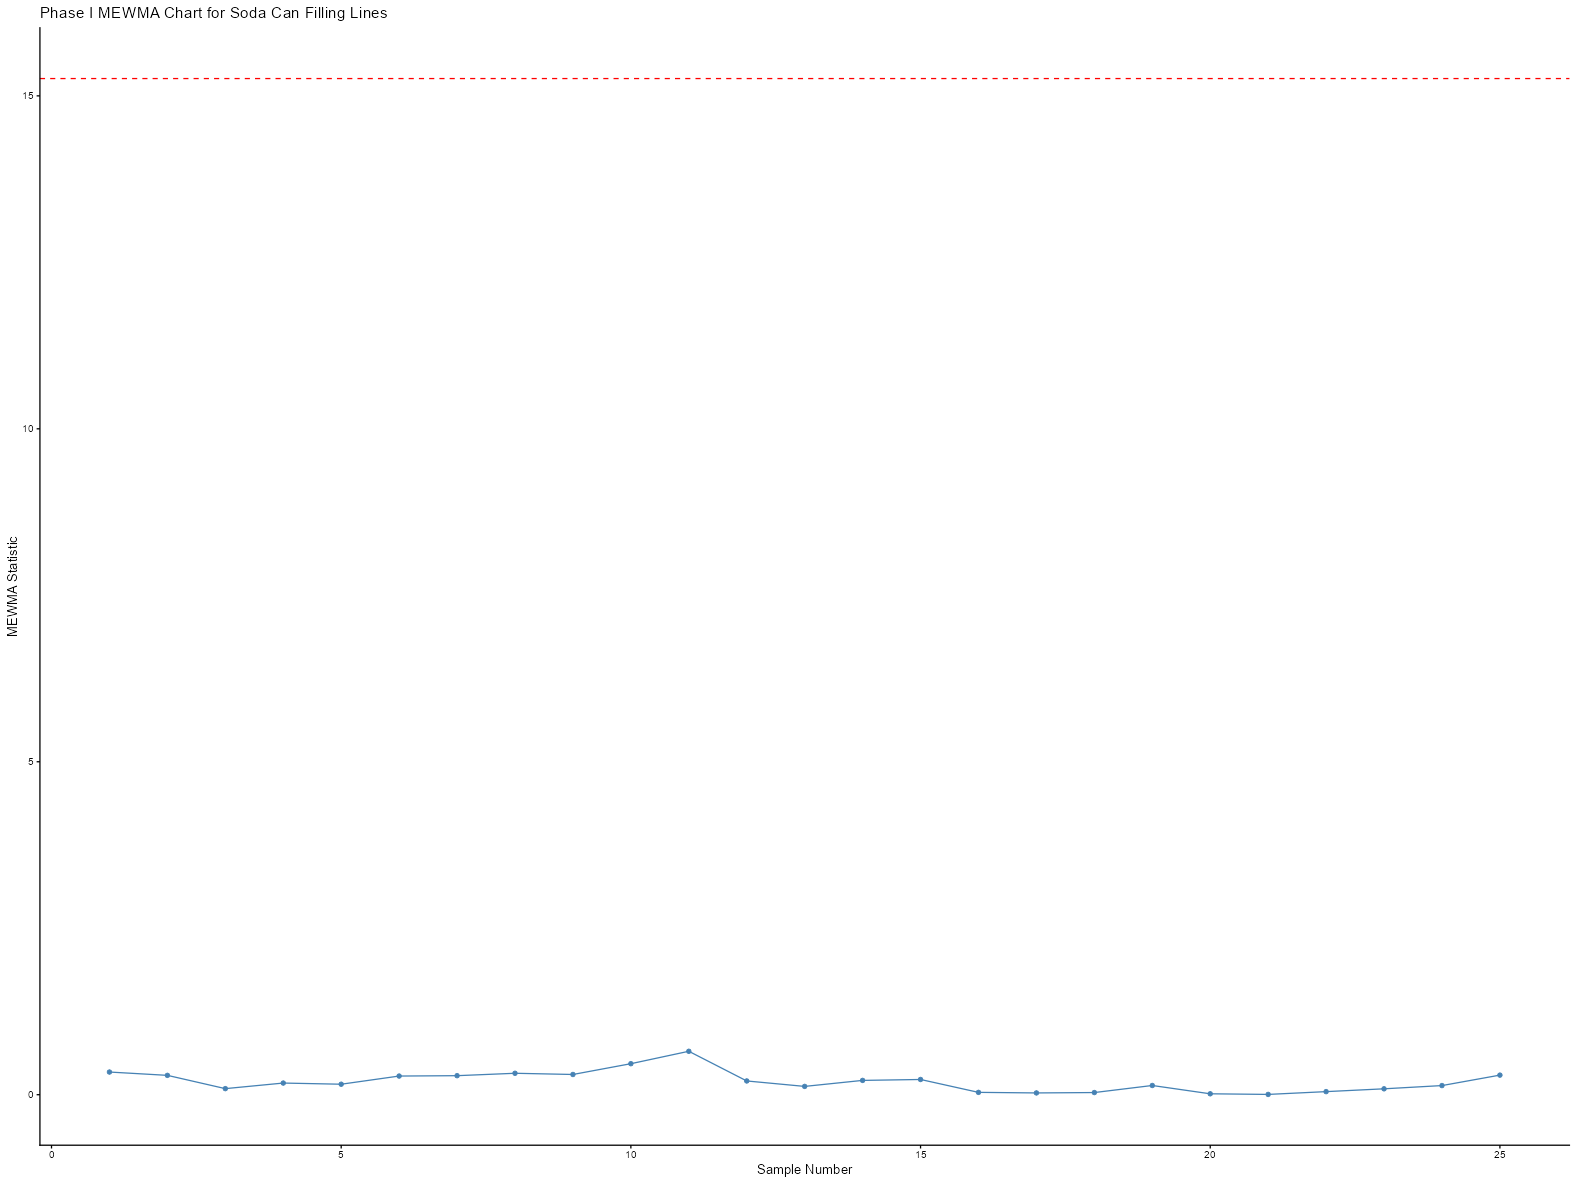

In [16]:
## Choose H = 15.26 as control limit and plot Phase I ##

ggplot() +
  geom_hline(yintercept=15.26,linetype="dashed",color='red') +
  geom_point(aes(x=1:nrow(p1_means),y=mewma1),color='steelblue') +
  geom_line(aes(x=1:nrow(p1_means),y=mewma1),color='steelblue') +
  labs(title="Phase I MEWMA Chart for Soda Can Filling Lines",
       x="Sample Number",
       y="MEWMA Statistic") +
  theme_classic()

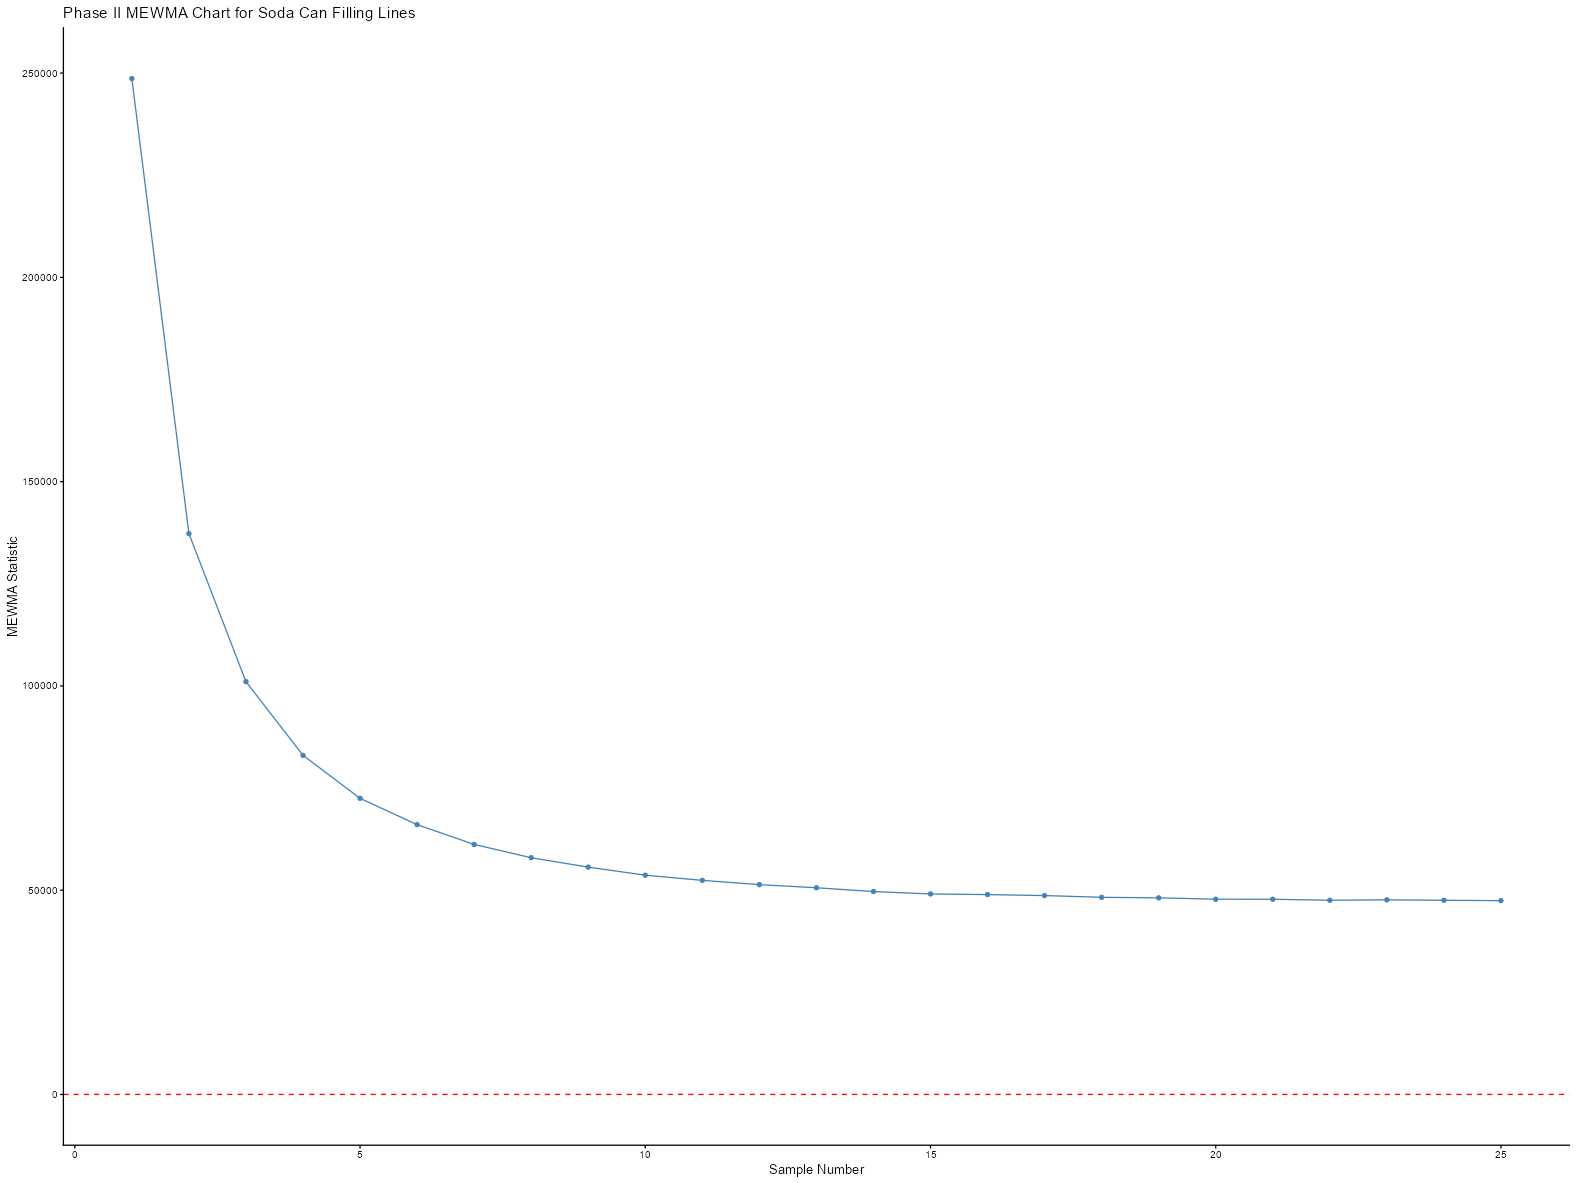

In [17]:
ggplot() +
  geom_hline(yintercept=15.26,linetype="dashed",color='red') +
  geom_point(aes(x=1:nrow(p1_means),y=mewma2),color='steelblue') +
  geom_line(aes(x=1:nrow(p1_means),y=mewma2),color='steelblue') +
  labs(title="Phase II MEWMA Chart for Soda Can Filling Lines",
       x="Sample Number",
       y="MEWMA Statistic") +
  theme_classic()

Same story as the $T^2$ chart: the process goes out of control immediately in Phase II.

## Post-Hoc Analysis: Which Line Went OOC?

Just like with the $T^2$ chart, once the MEWMA signals an out-of-control process, we still need a post-hoc step to figure out *which* stream is actually the problem. This time, instead of individual $\bar{X}/s$ charts, we'll use individual **univariate EWMA** charts per line — the natural follow-up analysis, since we're already using EWMA-style smoothing at the multivariate level.

Using $\lambda = 0.10$ means we should pair it with $L = 2.814$, consistent with the univariate EWMA ARL table from a couple weeks ago.

In [18]:
## Let's use individual EWMA control charts to determine which one
## went OOC ##

## If we're using lambda = 0.1, let's use L = 2.814 ##

L <- 2.814

## c4 for n = 10 is 0.9727 ##

c4 <- 0.9727

### Line 1

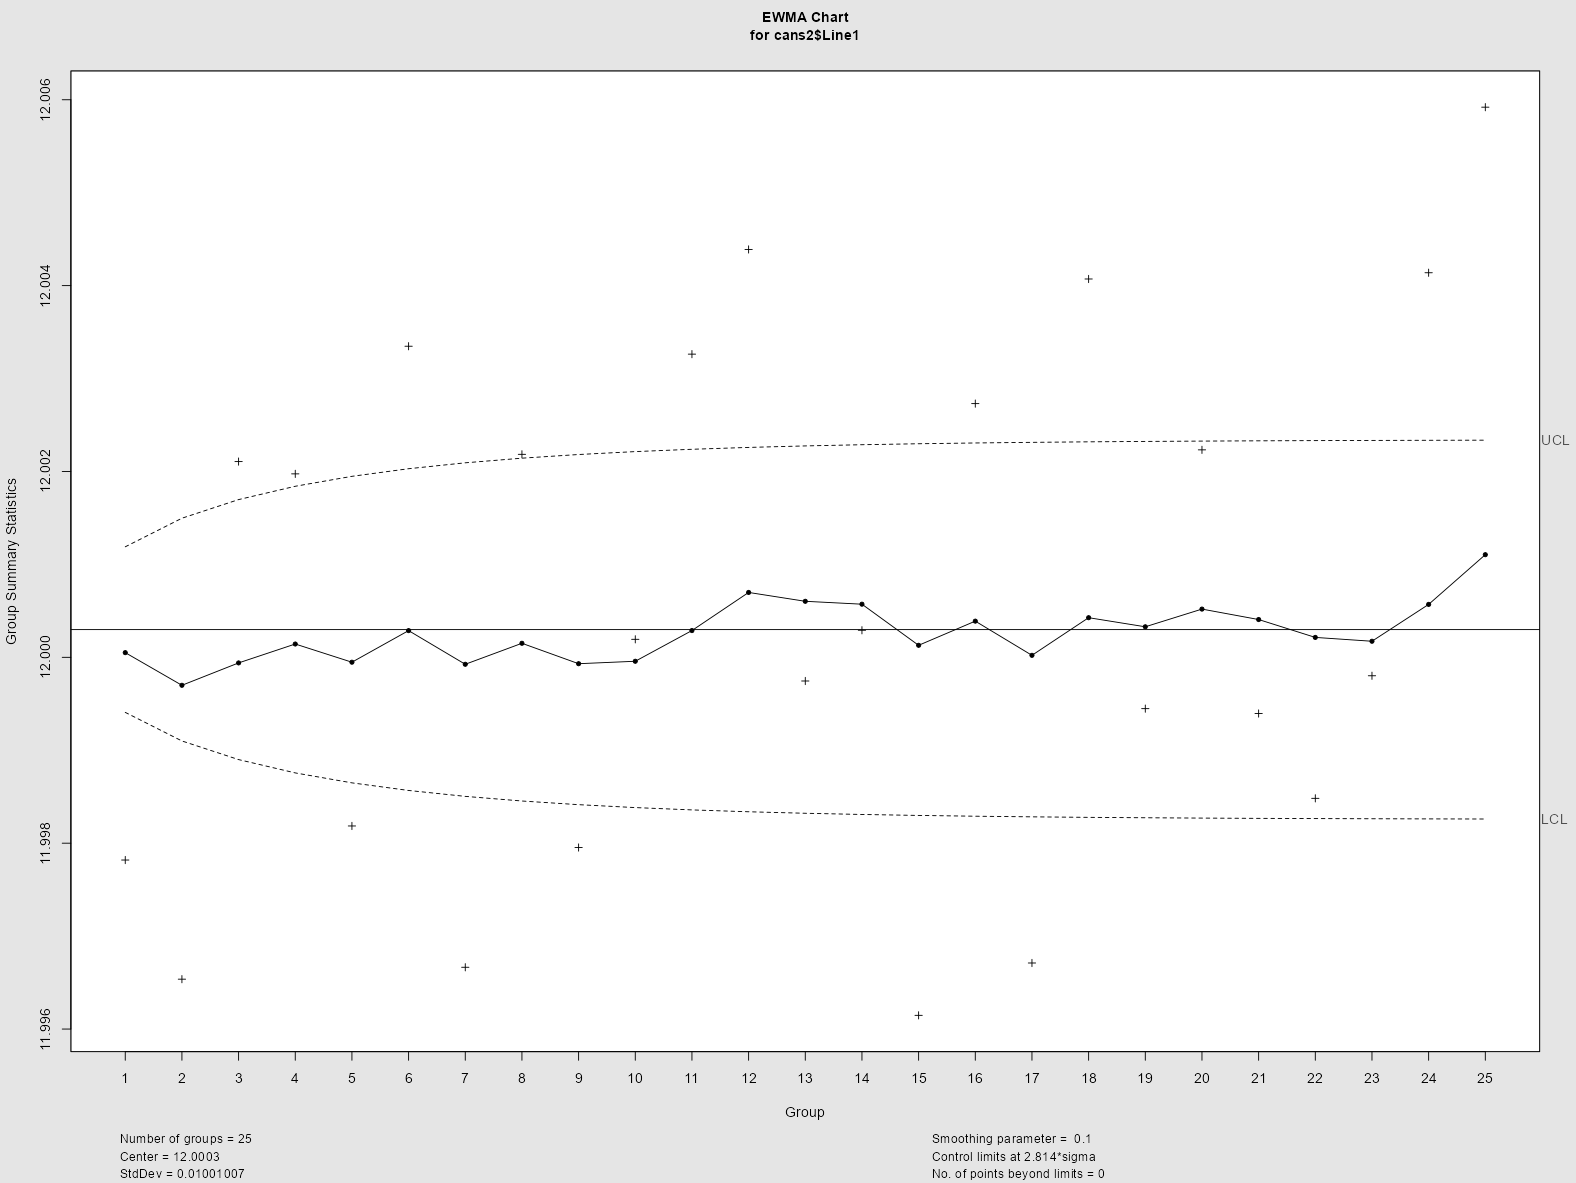

List of 15
 $ call      : language ewma(data = cans2$Line1, center = t2$center[1], lambda = 0.1, nsigmas = L, sigma = sqrt(t2$cov[1, 1]/c4))
 $ type      : chr "ewma"
 $ data.name : chr "cans2$Line1"
 $ data      : num [1:25, 1:10] 12 12 12 12 12 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 12 12 12 12 12 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 10 10 10 10 10 10 10 10 10 10 ...
 $ center    : Named num 12
  ..- attr(*, "names")= chr "Line1"
 $ std.dev   : num 0.01
 $ x         : int [1:25] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:25] 12 12 12 12 12 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sigma     : num [1:25] 0.000317 0.000426 0.000497 0.000548 0.000586 ...
 $ lambda    : num 0.1
 $ nsigmas   : num 2.81
 $ limits    : num [1:25, 1:2] 12 12 12 12 12 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int(0) 
  ..- attr(*, "names")= chr(0) 
 - attr(*, "class")= chr "ewma.qc

In [19]:
ewma(cans2$Line1,
     center=t2$center[1],
     lambda=0.1,sigma=sqrt(t2$cov[1,1]/c4),
     nsigmas=L)

### Line 2

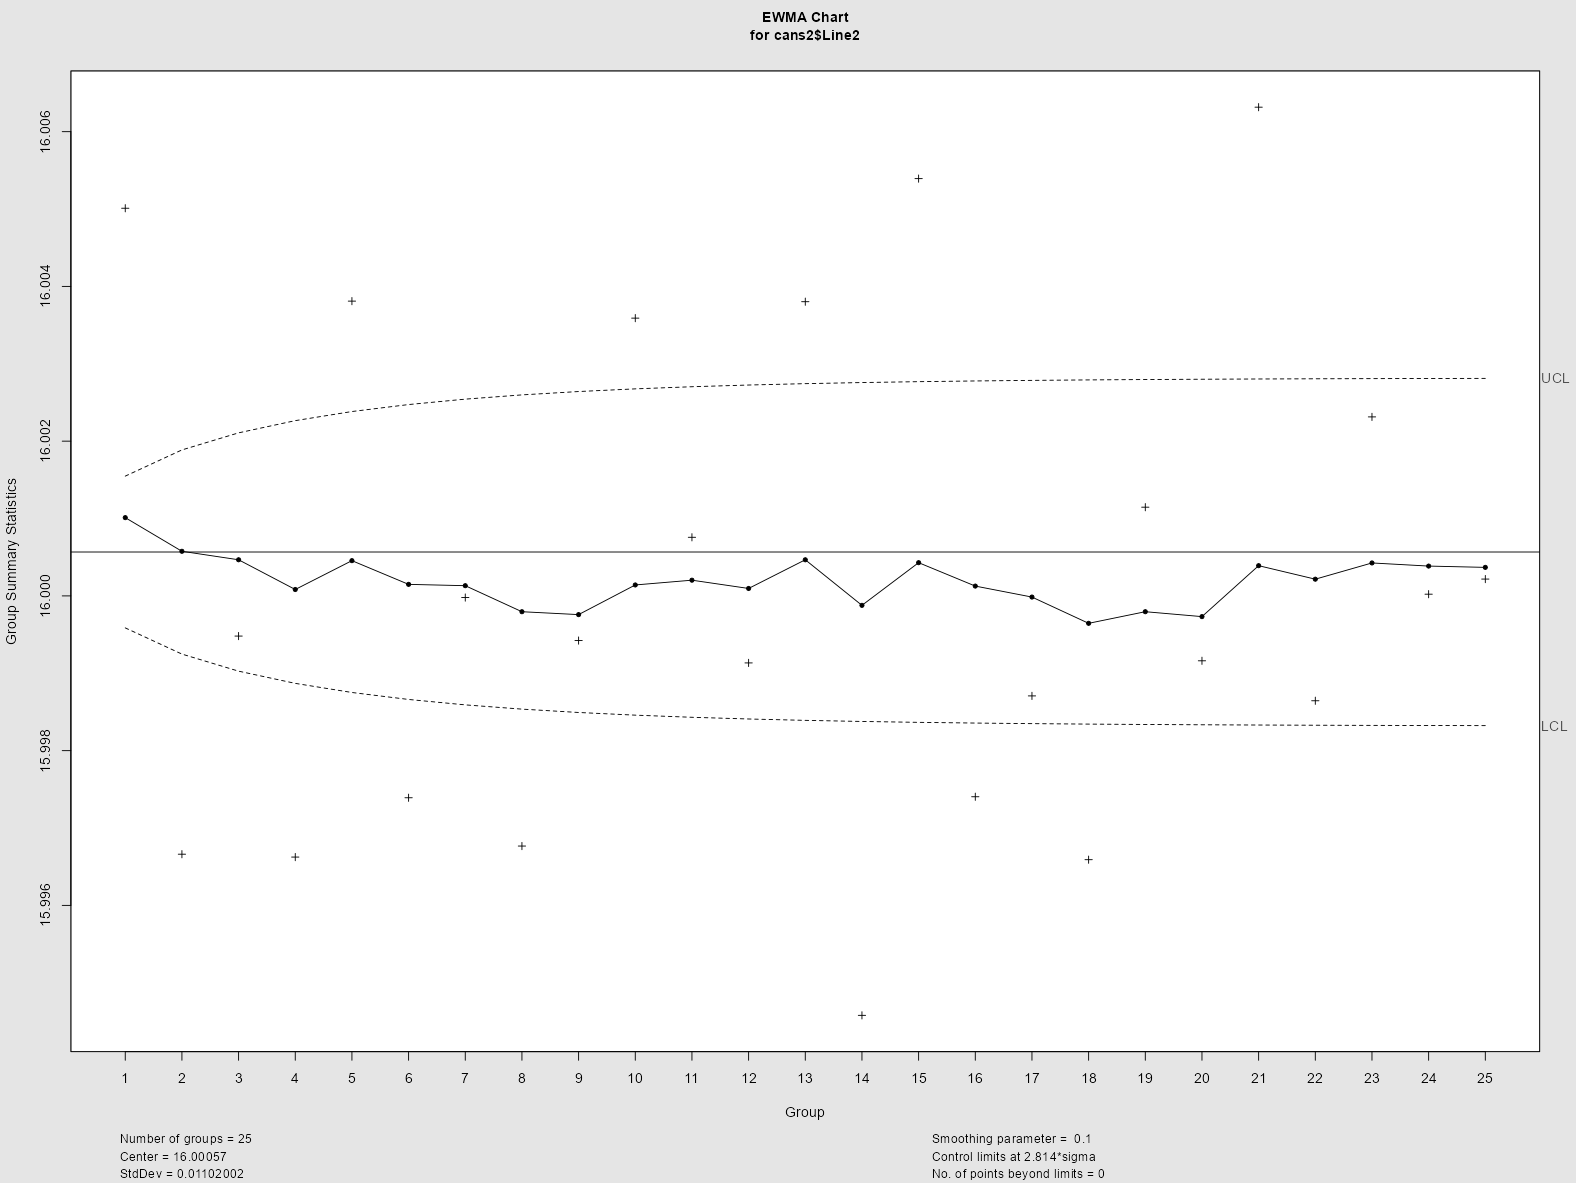

List of 15
 $ call      : language ewma(data = cans2$Line2, center = t2$center[2], lambda = 0.1, nsigmas = L, sigma = sqrt(t2$cov[2, 2]/c4))
 $ type      : chr "ewma"
 $ data.name : chr "cans2$Line2"
 $ data      : num [1:25, 1:10] 16 16 16 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 16 16 16 16 16 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 10 10 10 10 10 10 10 10 10 10 ...
 $ center    : Named num 16
  ..- attr(*, "names")= chr "Line2"
 $ std.dev   : num 0.011
 $ x         : int [1:25] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:25] 16 16 16 16 16 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sigma     : num [1:25] 0.000348 0.000469 0.000547 0.000603 0.000645 ...
 $ lambda    : num 0.1
 $ nsigmas   : num 2.81
 $ limits    : num [1:25, 1:2] 16 16 16 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int(0) 
  ..- attr(*, "names")= chr(0) 
 - attr(*, "class")= chr "ewma.q

In [20]:
ewma(cans2$Line2,center=t2$center[2],lambda=0.1,sigma=sqrt(t2$cov[2,2]/c4),
     nsigmas=L)

### Line 3

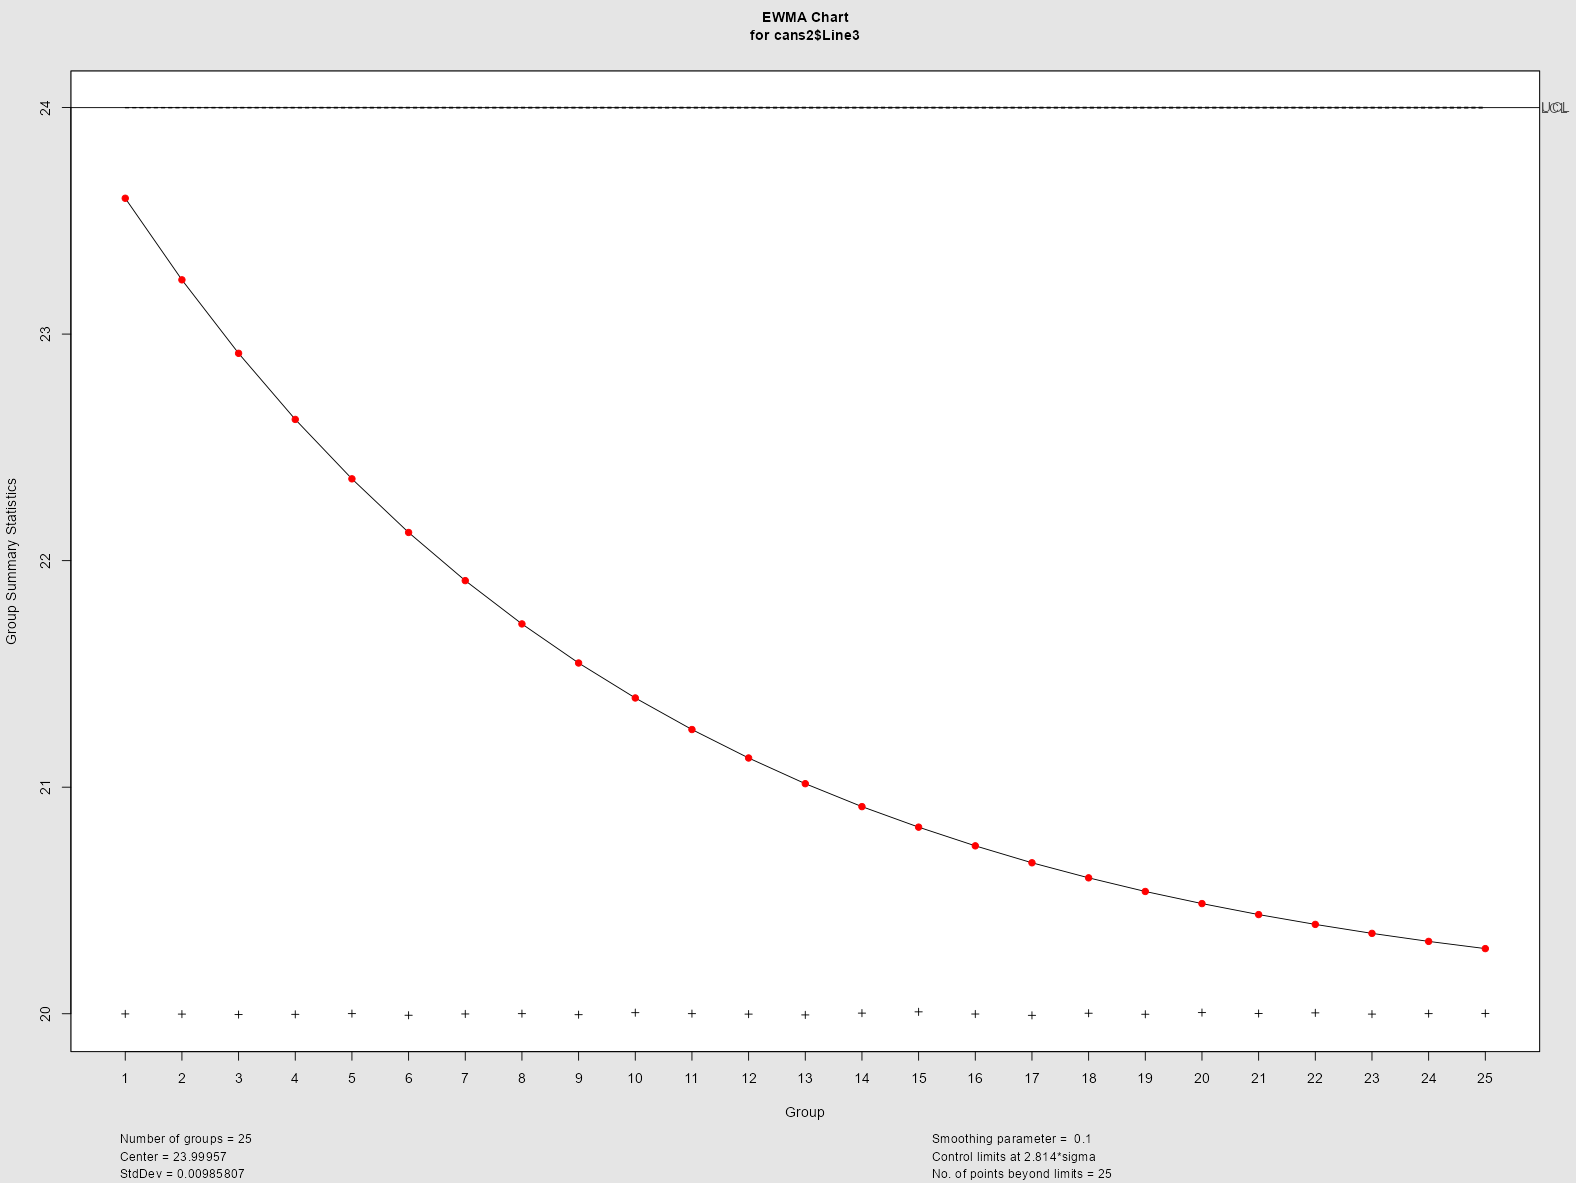

List of 15
 $ call      : language ewma(data = cans2$Line3, center = t2$center[3], lambda = 0.1, nsigmas = L, sigma = sqrt(t2$cov[3, 3]/c4))
 $ type      : chr "ewma"
 $ data.name : chr "cans2$Line3"
 $ data      : num [1:25, 1:10] 20 20 20 20 20 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 20 20 20 20 20 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 10 10 10 10 10 10 10 10 10 10 ...
 $ center    : Named num 24
  ..- attr(*, "names")= chr "Line3"
 $ std.dev   : num 0.00986
 $ x         : int [1:25] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:25] 23.6 23.2 22.9 22.6 22.4 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sigma     : num [1:25] 0.000312 0.000419 0.00049 0.00054 0.000577 ...
 $ lambda    : num 0.1
 $ nsigmas   : num 2.81
 $ limits    : num [1:25, 1:2] 24 24 24 24 24 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:25] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "names")= ch

In [21]:
ewma(cans2$Line3,center=t2$center[3],lambda=0.1,sigma=sqrt(t2$cov[3,3]/c4),
     nsigmas=L)

Once again, very clearly: **Line 3 is the culprit**. Both the $T^2$-based and MEWMA-based post-hoc analyses land on the same conclusion — reassuring, since it means the two multivariate approaches agree on the diagnosis, even though the MEWMA chart is the more sensitive of the two to smaller, sustained shifts.

## Final Thoughts on Multivariate SPC

Across both the $T^2$ and MEWMA charts, we've seen how multivariate control charts let us monitor processes with multiple, related quality characteristics — correcting for the inflated false alarm rate of running separate charts, and catching joint patterns that individual charts would miss entirely.

But there's a real cost: **complexity**. Aggregating a lot of information into a single plotting statistic means we can lose sight of what's actually happening in the process at a practical level — a chart telling you "something shifted" is a very different kind of signal than a chart telling you "the fill volume is running low." That's exactly why the post-hoc step (individual $\bar{X}/s$ or EWMA charts) isn't optional — it's how we translate a multivariate signal back into something actionable.

And while our examples made it obvious which stream was out of control, that won't always be the case in practice. Real processes can have far more than three correlated streams, weaker signal-to-noise ratios, or multiple streams shifting at once — situations where isolating the root cause takes real investigative work, not just a glance at three follow-up charts.

## Further Reading

1. [Bersimis, Psarakis, Panaretos (2007)](https://onlinelibrary.wiley.com/doi/abs/10.1002/qre.829?casa_token=dh1rJ8dMDuYAAAAA%3Aai3fuJdJRvLxv52kUTjZ1M4aIRqT2pkaX2pYiOMcRwv9OoFc7nNAUGfpW1HIA2o1PuHrH_1JNpxSkuEU)
2. [Woodall and Montgomery (2014)](https://www.tandfonline.com/doi/abs/10.1080/00224065.2014.11917955)
3. [De Ketelaere, Hubert, and Schmitt (2015)](https://www.tandfonline.com/doi/abs/10.1080/00224065.2015.11918137)
4. [Johannssen et al., (2025)](https://www.sciencedirect.com/science/article/pii/S0360835225005534)